#Breast Cancer Wisconsin Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


In [ ]:
df = pd.read_csv("data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df = df.drop(["id", "Unnamed: 32"], axis=1)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print( outliers[outliers > 0])

radius_mean                14
texture_mean                7
perimeter_mean             13
area_mean                  25
smoothness_mean             6
compactness_mean           16
concavity_mean             18
concave points_mean        10
symmetry_mean              15
fractal_dimension_mean     15
radius_se                  38
texture_se                 20
perimeter_se               38
area_se                    65
smoothness_se              30
compactness_se             28
concavity_se               22
concave points_se          19
symmetry_se                27
fractal_dimension_se       28
radius_worst               17
texture_worst               5
perimeter_worst            15
area_worst                 35
smoothness_worst            7
compactness_worst          16
concavity_worst            12
symmetry_worst             23
fractal_dimension_worst    24
dtype: int64


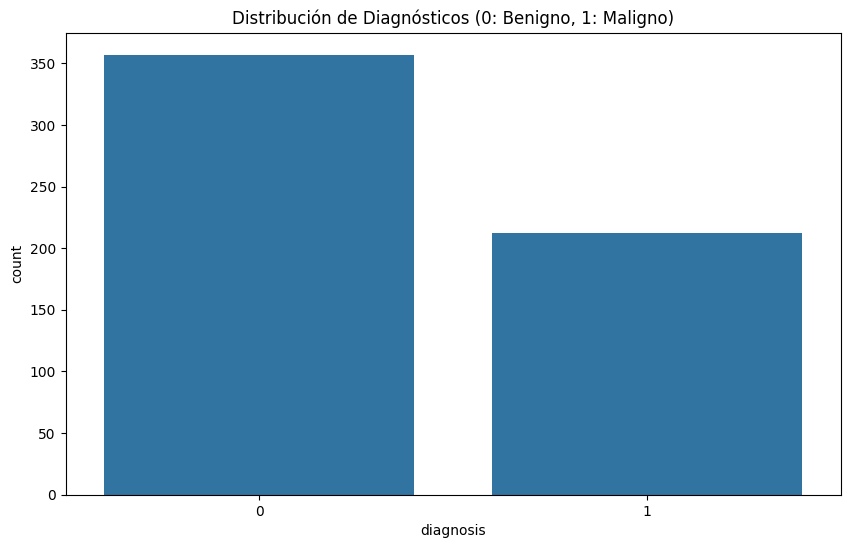

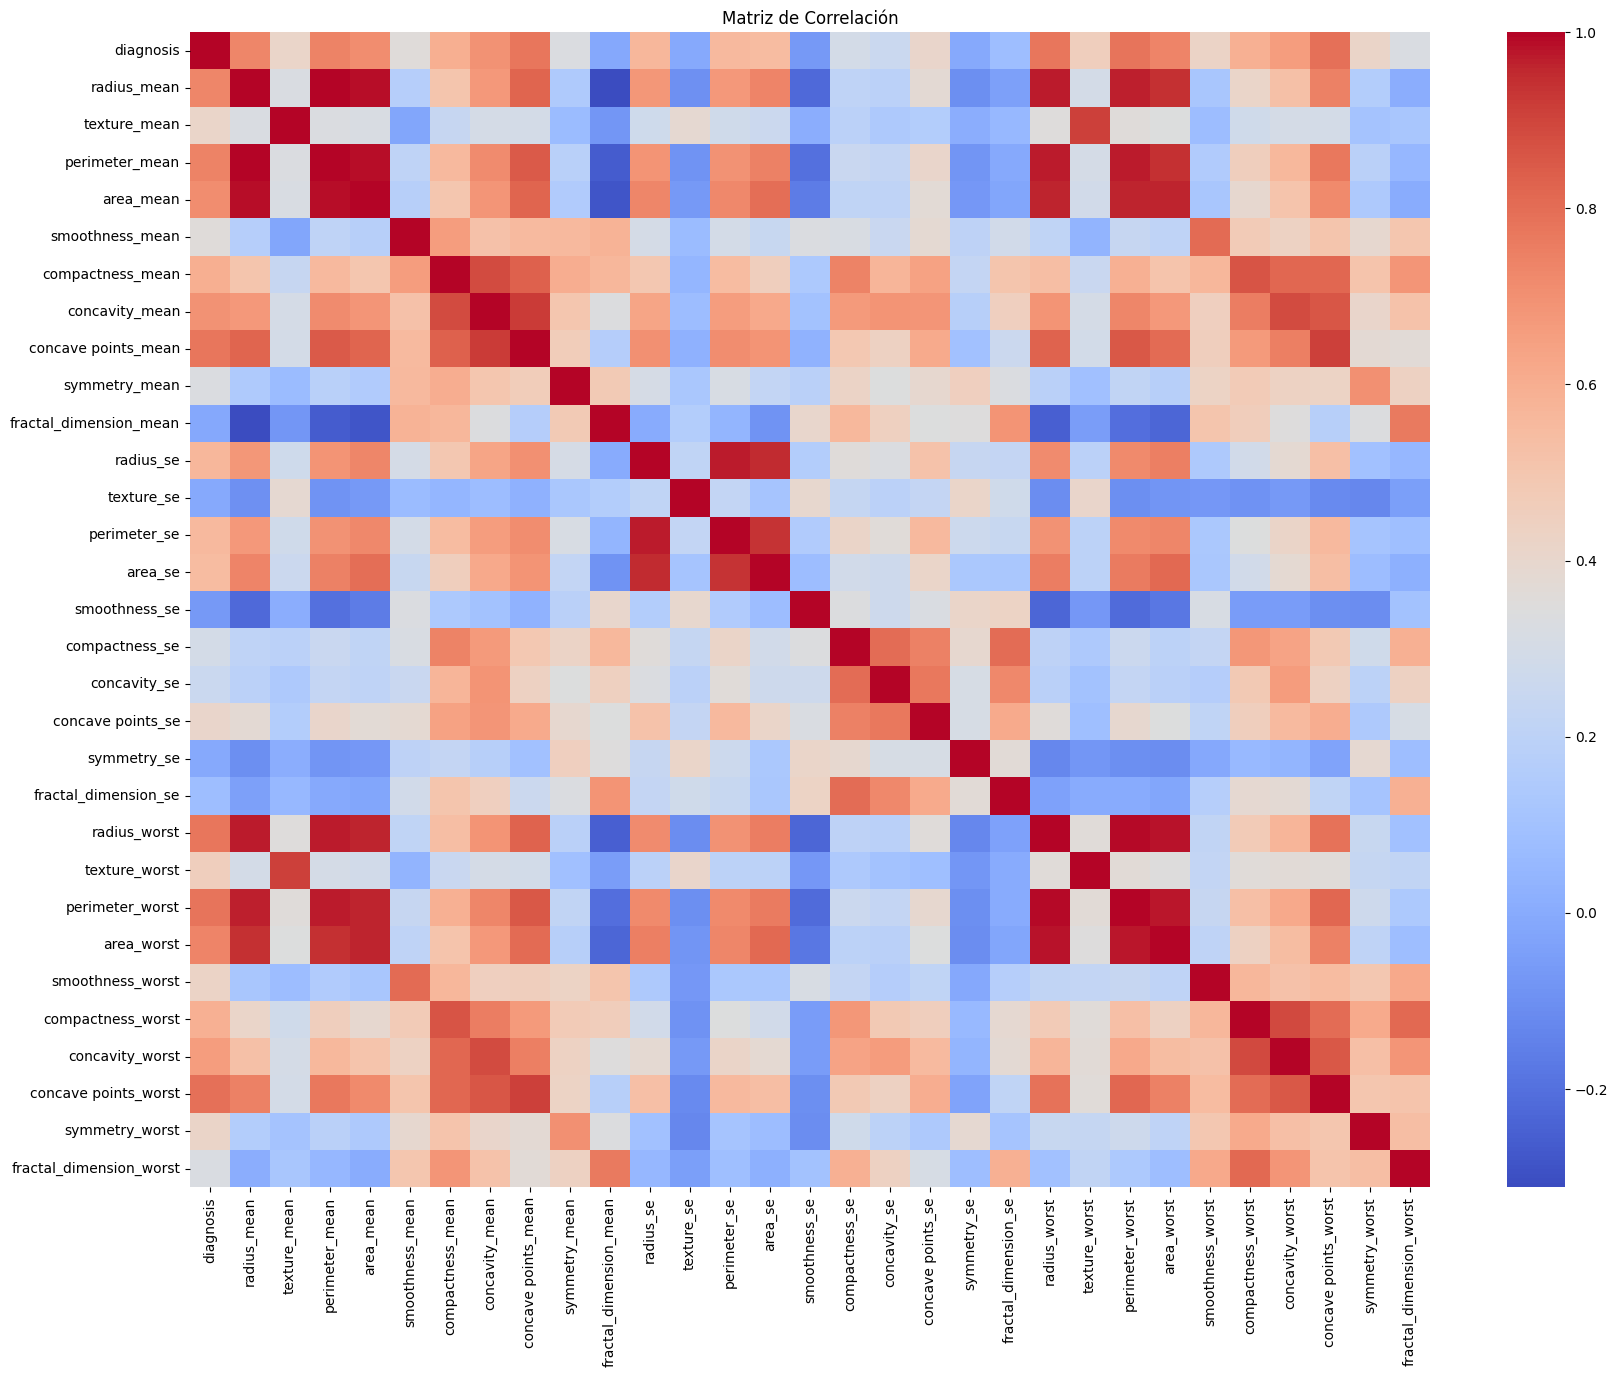

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribución de Diagnósticos (0: Benigno, 1: Maligno)')
plt.show()

plt.figure(figsize=(20,15))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

##Modelos de clasificación

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

param_grid_dt = {'max_depth': [3, 5, 10, 15, None]}
dt_model = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(dt_model, param_grid_dt, cv=10, scoring='accuracy')
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
cv_scores_dt = cross_val_score(best_dt, X_train, y_train, cv=10)

print(cv_scores_dt)
print(f"accuracy {cv_scores_dt.mean():.3f} (+/- {cv_scores_dt.std() * 2:.5f})")

[0.97826087 0.91304348 0.97826087 0.84782609 0.93478261 0.95555556
 0.97777778 0.95555556 0.97777778 0.88888889]
accuracy 0.941 (+/- 0.08514)


Decision Tree - Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        71
           1       0.95      0.91      0.93        43

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



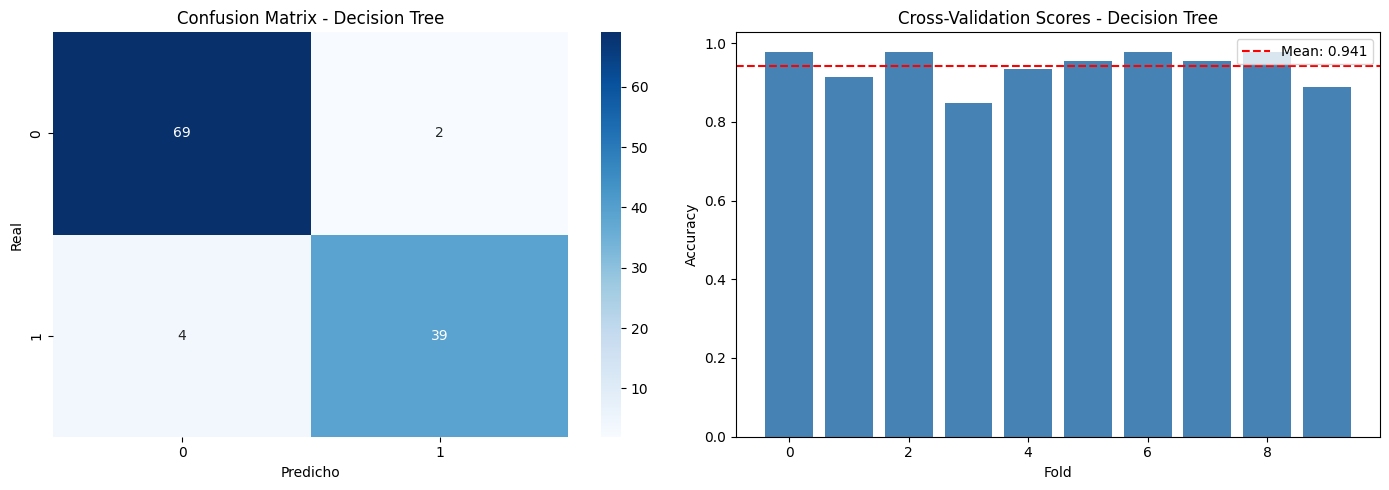

In [ ]:
# Evaluación y gráfica - Decision Tree
y_pred_dt = best_dt.predict(X_test)
print("Decision Tree - Classification Report:")
print(classification_report(y_test, y_pred_dt))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Decision Tree")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

# Cross-val scores
axes[1].bar(range(len(cv_scores_dt)), cv_scores_dt, color="steelblue")
axes[1].axhline(cv_scores_dt.mean(), color="red", linestyle="--", label=f"Mean: {cv_scores_dt.mean():.3f}")
axes[1].set_title("Cross-Validation Scores - Decision Tree")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {'n_estimators': [50, 100, 200]}
rf_model = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(rf_model, param_grid_rf, cv=10, scoring='accuracy')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
cv_scores_rf = cross_val_score(best_rf, X_train, y_train, cv=10)

print(cv_scores_rf)
print(f"accuracy {cv_scores_rf.mean():.3f} (+/- {cv_scores_rf.std() * 2:.5f})")

[1.         0.95652174 0.97826087 0.91304348 0.97826087 0.97777778
 0.97777778 0.95555556 0.97777778 0.95555556]
accuracy 0.967 (+/- 0.04461)


Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



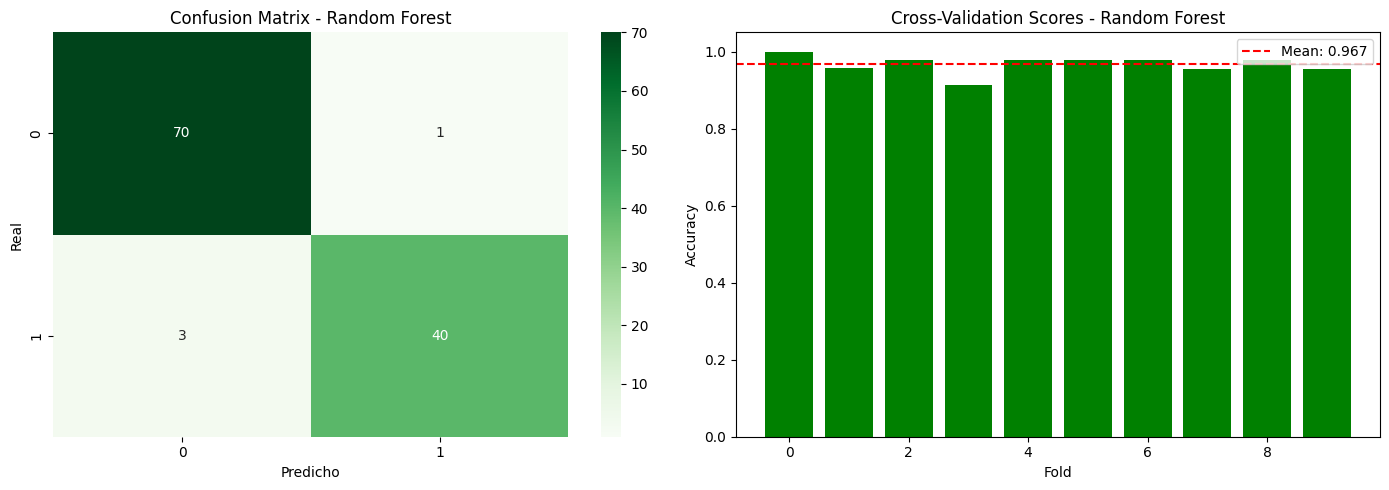

In [ ]:
# Evaluación y gráfica - Random Forest
y_pred_rf = best_rf.predict(X_test)
print("Random Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[0])
axes[0].set_title("Confusion Matrix - Random Forest")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

axes[1].bar(range(len(cv_scores_rf)), cv_scores_rf, color="green")
axes[1].axhline(cv_scores_rf.mean(), color="red", linestyle="--", label=f"Mean: {cv_scores_rf.mean():.3f}")
axes[1].set_title("Cross-Validation Scores - Random Forest")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


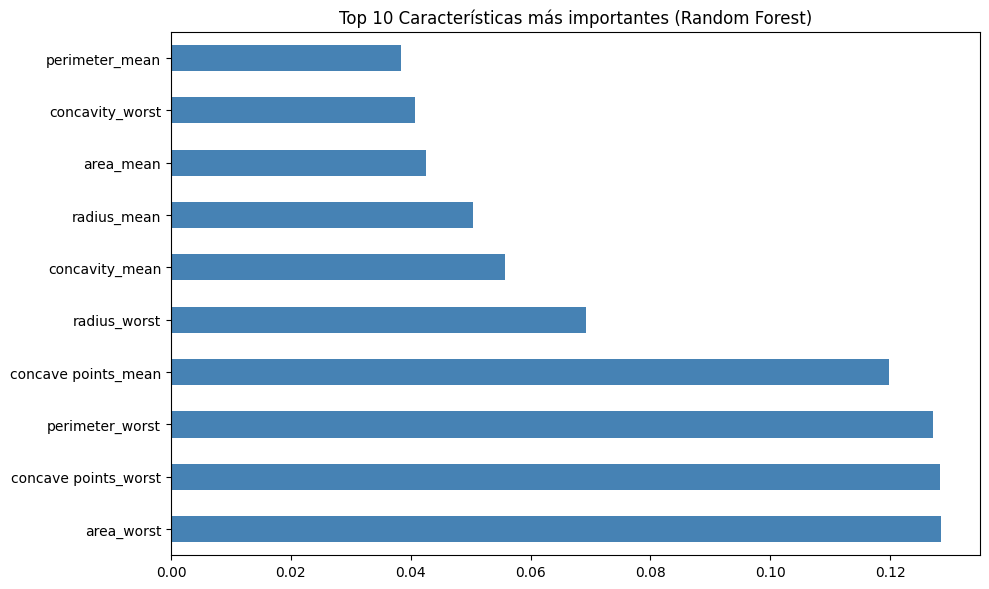

In [ ]:
# Feature importances - Random Forest
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind="barh", color="steelblue")
plt.title("Top 10 Características más importantes (Random Forest)")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.svm import SVC

param_grid_svm = {'kernel': ['linear', 'poly', 'rbf'], 'C': [1, 10]}
svm_model = SVC(random_state=42)

grid_svm = GridSearchCV(svm_model, param_grid_svm, cv=10, scoring='accuracy')
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
cv_scores_svm = cross_val_score(best_svm, X_train, y_train, cv=10)

print(cv_scores_svm)
print(f"accuracy {cv_scores_svm.mean():.3f} (+/- {cv_scores_svm.std() * 2:.5f})")

[0.95652174 0.95652174 0.97826087 0.93478261 1.         0.93333333
 0.97777778 0.97777778 0.97777778 0.86666667]
accuracy 0.956 (+/- 0.07155)


SVM - Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



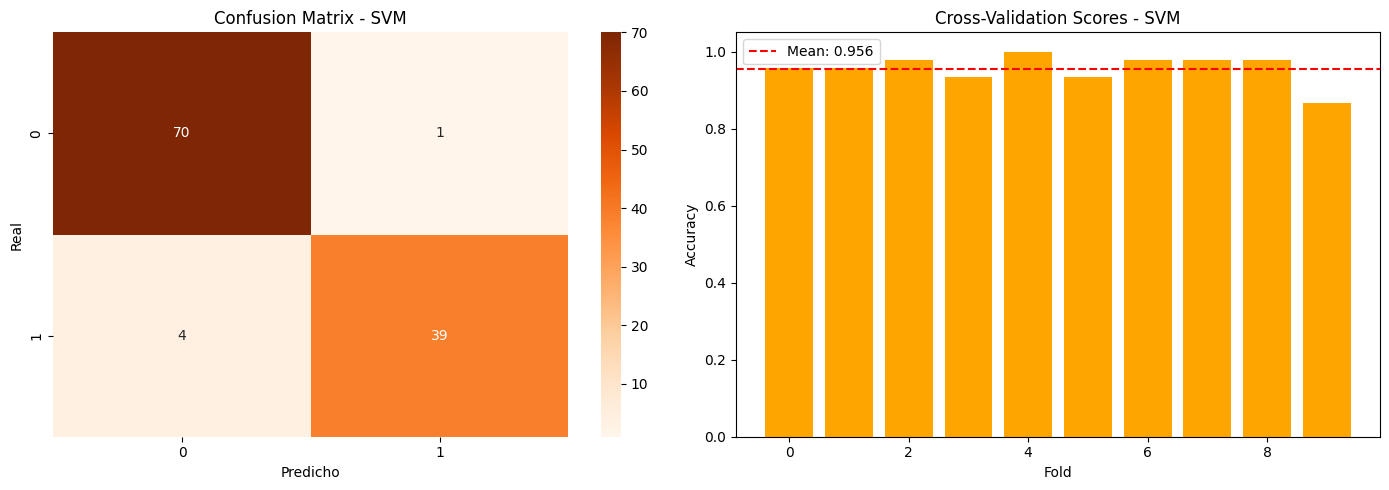

In [ ]:
# Evaluación y gráfica - SVM
y_pred_svm = best_svm.predict(X_test)
print("SVM - Classification Report:")
print(classification_report(y_test, y_pred_svm))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Oranges", ax=axes[0])
axes[0].set_title("Confusion Matrix - SVM")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

axes[1].bar(range(len(cv_scores_svm)), cv_scores_svm, color="orange")
axes[1].axhline(cv_scores_svm.mean(), color="red", linestyle="--", label=f"Mean: {cv_scores_svm.mean():.3f}")
axes[1].set_title("Cross-Validation Scores - SVM")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Modelo de 3 Capas (64, 128, 128)

In [ ]:
model_1 = Sequential()
model_1.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model_1.add(Dense(128, activation='relu'))
model_1.add(Dense(128, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))

model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Modelo de 6 Capas (64, 64, 128, 128, 256, 256)

In [ ]:
model_2 = Sequential()
model_2.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model_2.add(Dense(64, activation='relu'))
model_2.add(Dense(128, activation='relu'))
model_2.add(Dense(128, activation='relu'))
model_2.add(Dense(256, activation='relu'))
model_2.add(Dense(256, activation='relu'))
model_2.add(Dense(1, activation='sigmoid'))

model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#3. Modelo de 10 Capas de 128

In [ ]:
model_3 = Sequential()
model_3.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
for _ in range(9):
    model_3.add(Dense(128, activation='relu'))
model_3.add(Dense(1, activation='sigmoid'))

model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history_1 = model_1.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))
history_2 = model_2.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))
history_3 = model_3.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8725 - loss: 0.4194 - val_accuracy: 0.9561 - val_loss: 0.1849
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9648 - loss: 0.1353 - val_accuracy: 0.9912 - val_loss: 0.0746
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9824 - loss: 0.0804 - val_accuracy: 0.9825 - val_loss: 0.0616
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9846 - loss: 0.0628 - val_accuracy: 0.9825 - val_loss: 0.0657
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9846 - loss: 0.0548 - val_accuracy: 0.9737 - val_loss: 0.0699
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9868 - loss: 0.0484 - val_accuracy: 0.9825 - val_loss: 0.0707
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9890 - loss: 0.0412 - val_accuracy: 0.9737 - val_loss: 0.0765
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9890 - loss: 0.0375 - val_accuracy: 0.9825 - val_loss

In [ ]:
loss_1, acc_1 = model_1.evaluate(X_test_scaled, y_test)
loss_2, acc_2 = model_2.evaluate(X_test_scaled, y_test)
loss_3, acc_3 = model_3.evaluate(X_test_scaled, y_test)

print(acc_1)
print(acc_2)
print(acc_3)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9737 - loss: 0.1484 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9737 - loss: 0.3710 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9649 - loss: 0.4933 
0.9736841917037964
0.9736841917037964
0.9649122953414917


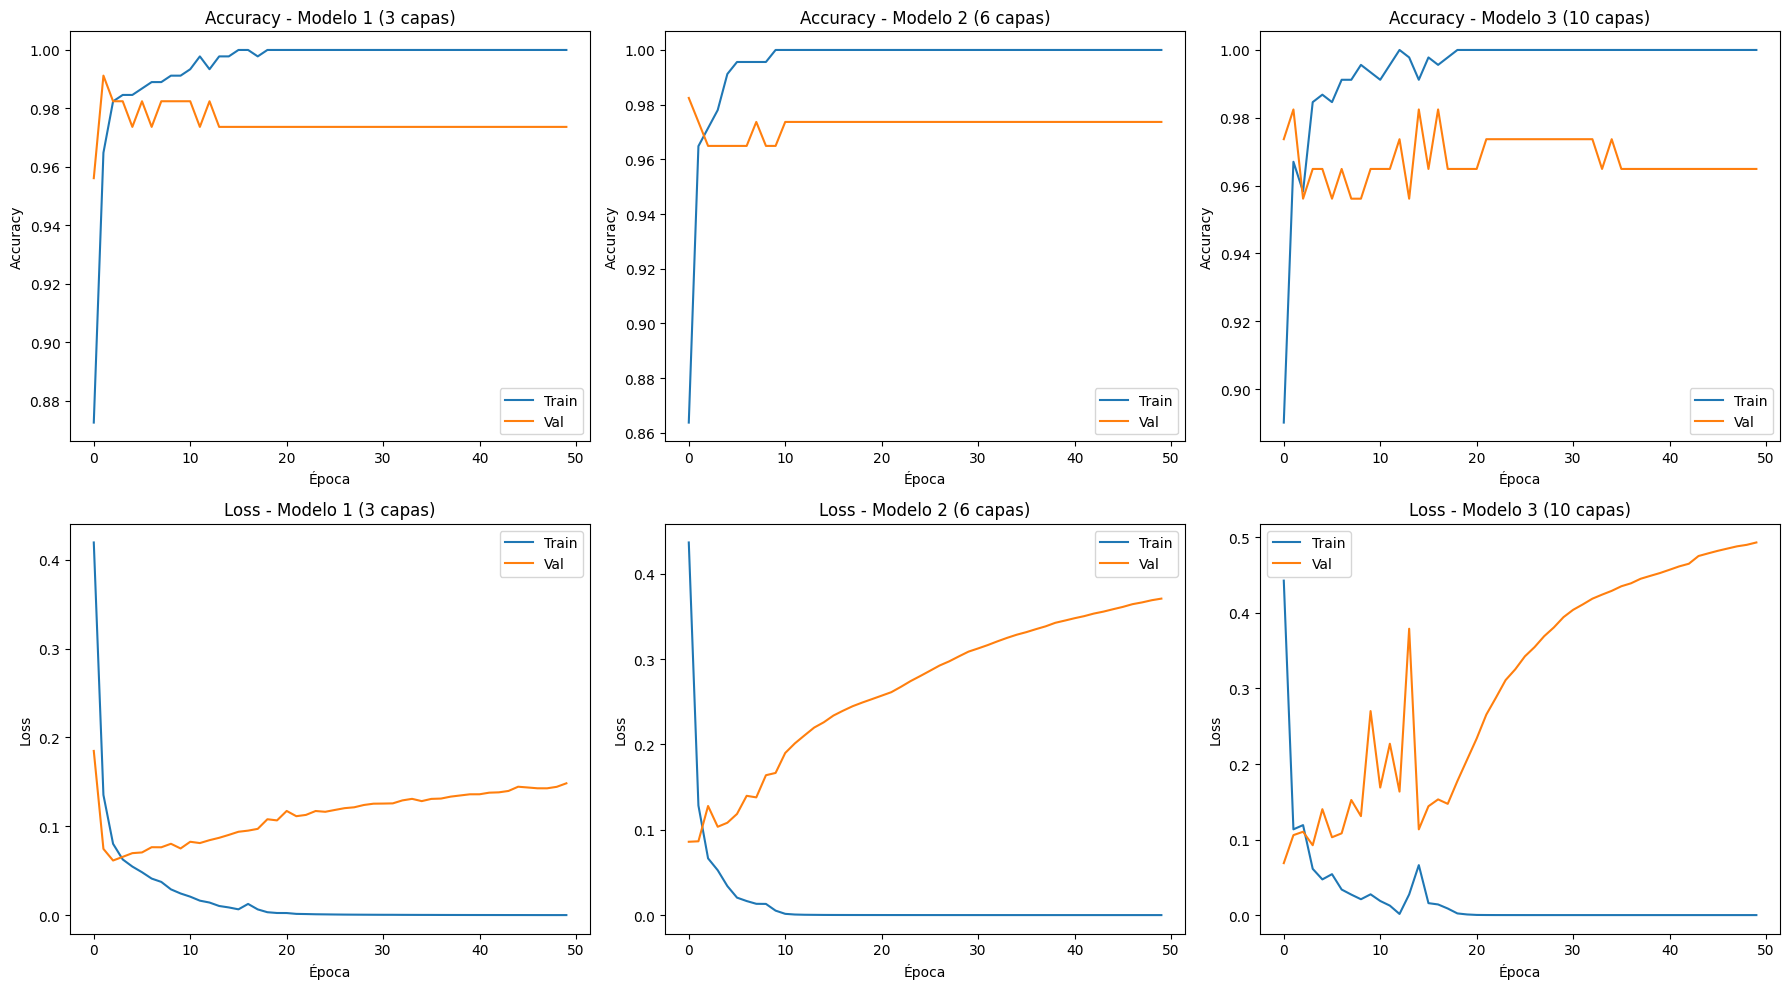

In [ ]:
# Gráficas - Deep Learning (accuracy y loss por época)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models_history = [history_1, history_2, history_3]
model_names = ["Modelo 1 (3 capas)", "Modelo 2 (6 capas)", "Modelo 3 (10 capas)"]

for i, (hist, name) in enumerate(zip(models_history, model_names)):
    axes[0, i].plot(hist.history["accuracy"], label="Train")
    axes[0, i].plot(hist.history["val_accuracy"], label="Val")
    axes[0, i].set_title(f"Accuracy - {name}")
    axes[0, i].set_xlabel("Época")
    axes[0, i].set_ylabel("Accuracy")
    axes[0, i].legend()

    axes[1, i].plot(hist.history["loss"], label="Train")
    axes[1, i].plot(hist.history["val_loss"], label="Val")
    axes[1, i].set_title(f"Loss - {name}")
    axes[1, i].set_xlabel("Época")
    axes[1, i].set_ylabel("Loss")
    axes[1, i].legend()

plt.tight_layout()
plt.show()


##1. Reducción de Dimensionalidad: PCA
De acuerdo a las notas del tema de reducción dimensional, utilizaremos PCA para proyectar nuestro dataset de alta dimensionalidad (30 características) a solo 2 componentes principales. Esto nos permitirá visualizar los datos en un plano 2D.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Varianza explicada por PC1: 44.27%
Varianza explicada por PC2: 18.97%
Varianza total explicada: 63.24%


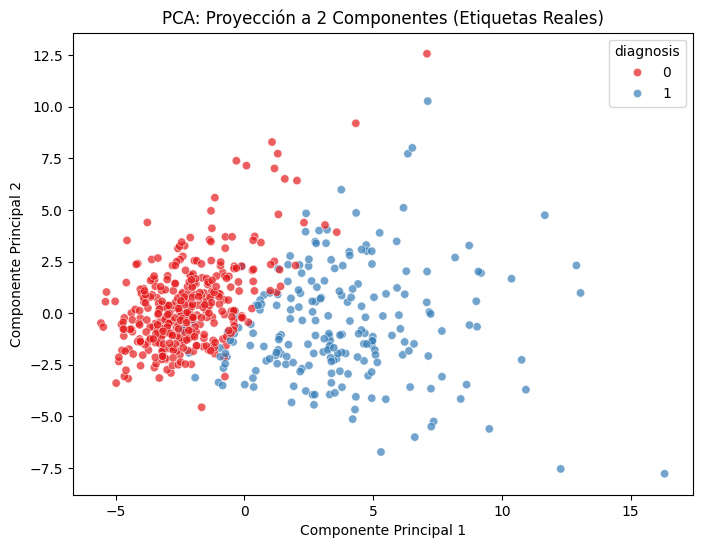

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
y_real = df['diagnosis']

df_pca = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])

varianza_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {varianza_explicada[0]:.2%}")
print(f"Varianza explicada por PC2: {varianza_explicada[1]:.2%}")
print(f"Varianza total explicada: {sum(varianza_explicada):.2%}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Componente Principal 1', y='Componente Principal 2',
                hue=y_real, palette='Set1', data=df_pca, alpha=0.7)
plt.title('PCA: Proyección a 2 Componentes (Etiquetas Reales)')
plt.show()

## 2. Aprendizaje No Supervisado: K-Means
Ahora, basándonos en las notas de aprendizaje no supervisado, aplicaremos el algoritmo **K-Means** para encontrar patrones agrupados (clusters) en los datos estandarizados, sin decirle al modelo cuáles son malignos o benignos. Sabemos empíricamente que buscamos 2 grupos (K=2).

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels_kmeans = kmeans.labels_
df_pca['Cluster_KMeans'] = labels_kmeans

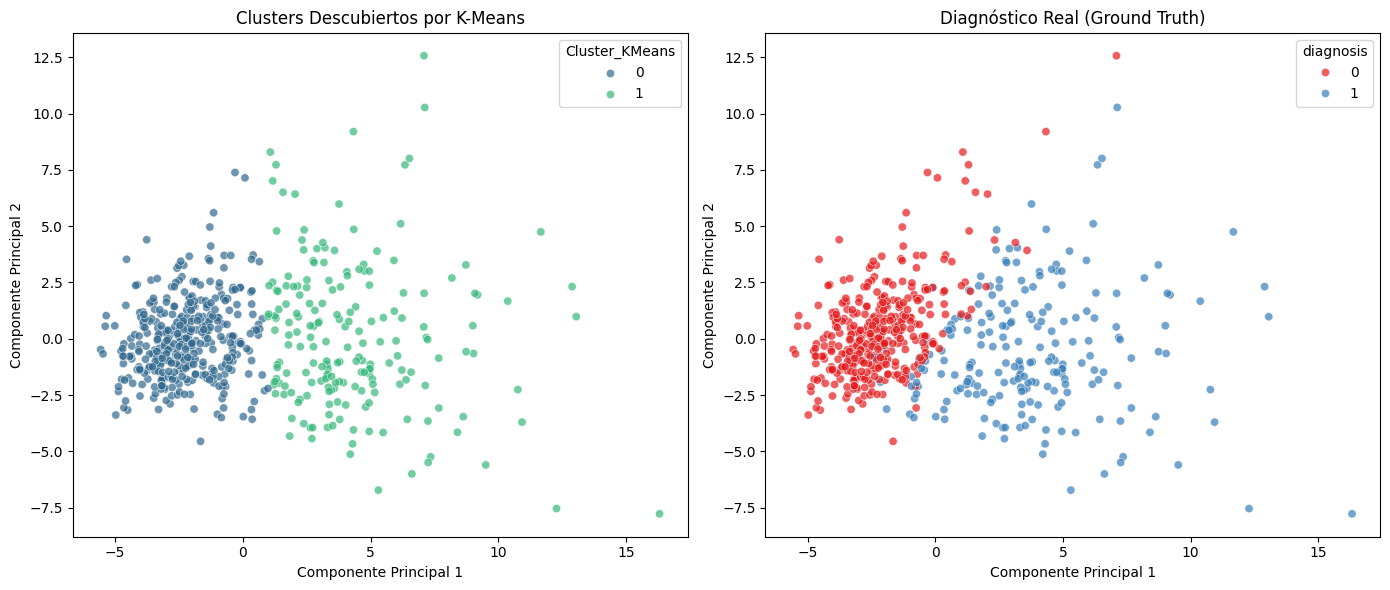

In [ ]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x='Componente Principal 1', y='Componente Principal 2',
                hue='Cluster_KMeans', palette='viridis', data=df_pca, alpha=0.7)
plt.title('Clusters Descubiertos por K-Means')
plt.subplot(1, 2, 2)
sns.scatterplot(x='Componente Principal 1', y='Componente Principal 2',
                hue=y_real, palette='Set1', data=df_pca, alpha=0.7)
plt.title('Diagnóstico Real (Ground Truth)')
plt.tight_layout()
plt.show()

## 3. Aprendizaje No Supervisado: DBSCAN
A diferencia de K-Means, que agrupa basándose en la distancia a un centroide, **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) agrupa los datos basándose en la densidad local. Es excelente para encontrar clústeres de formas irregulares y para identificar valores atípicos (ruido), los cuales marca con la etiqueta `-1`.

In [ ]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan.fit(X_scaled)
labels_dbscan = dbscan.labels_
df_pca['Cluster_DBSCAN'] = labels_dbscan
print(f"Etiquetas únicas encontradas (incluyendo ruido -1): {np.unique(labels_dbscan)}")

Etiquetas únicas encontradas (incluyendo ruido -1): [-1  0  1]


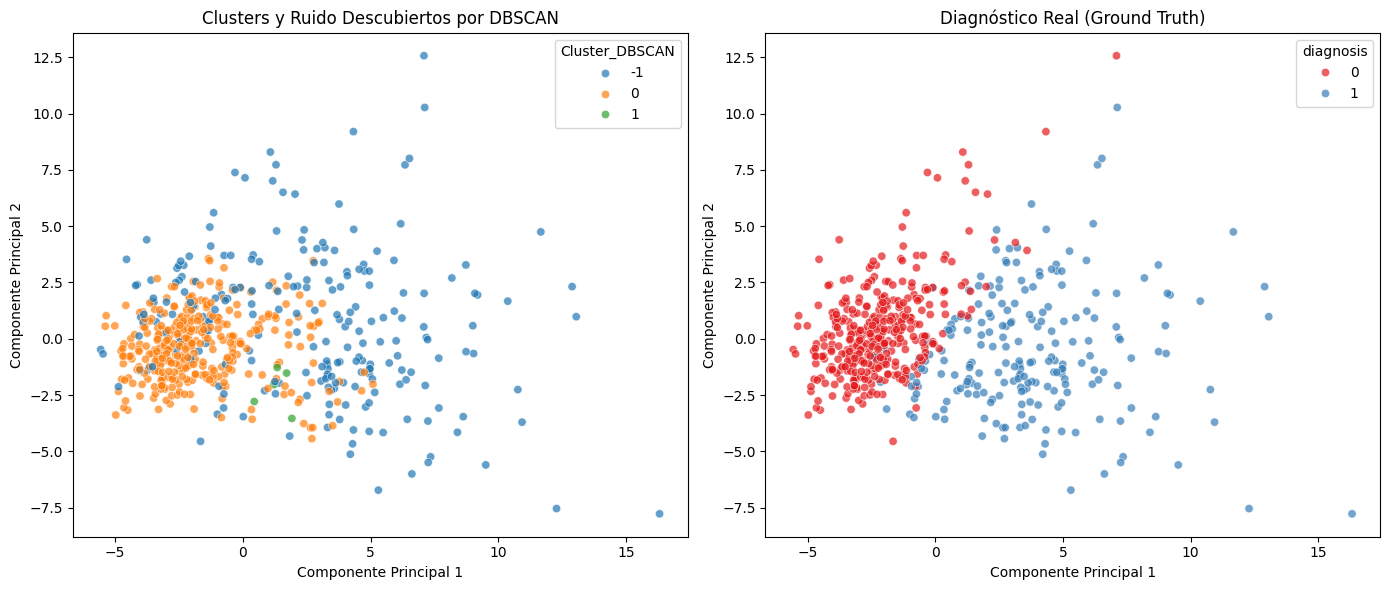

In [ ]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x='Componente Principal 1', y='Componente Principal 2',
                hue='Cluster_DBSCAN', palette='tab10', data=df_pca, alpha=0.7)
plt.title('Clusters y Ruido Descubiertos por DBSCAN')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Componente Principal 1', y='Componente Principal 2',
                hue=y_real, palette='Set1', data=df_pca, alpha=0.7)
plt.title('Diagnóstico Real (Ground Truth)')

plt.tight_layout()
plt.show()